In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from Preprocess import preprocess_data
from Preprocess import preprocess_data_window

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time,
    data_orig,
    n_previous_events=20
)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
Next slips shape (4897, 8)
orig shape (5150, 8)
X shape:  (2822, 126)
y shape:  (2822,)


In [5]:

alphas = np.logspace(-2,8) #Testing alpha values between 10^-2 and 10^8
val_RMSE =[] # list to store the results from each alpha for comparison
print(X_train)
# Running each alpha through the ridge regression, testing how well it does on the validation data, then storing the result in the above list for comparison
for a in alphas:
  model = Ridge(alpha=a)
  model.fit(X_train, y_train) #These may be the wrong data type, but they still need to be kept normalized...
  y_prediction_val = model.predict(X_val)
  RMSE = root_mean_squared_error(y_val, y_prediction_val)
  val_RMSE.append(RMSE)

# Selecting the alpha that minimizes the error
optimal_alpha = alphas[np.argmin(val_RMSE)]
print("Optimal Alpha Value:", optimal_alpha)

# Combining the training and validation sets into all training for the final 
#X_train = pd.DataFrame(X_train, columns=feature_cols)
#y_train = pd.DataFrame(y_train, columns=feature_cols)
#X_full_train = pd.concat([X_train, X_val])
#y_full_train = pd.concat([y_train, y_val])

X_full_train = np.concatenate([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])

# Sanity check
#print(len(X_full_train) == len(y_full_train))
#print(X_full_train.shape)
#print(y_full_train.shape)

# Final ridge regression on test data
Ridge_model = Ridge(alpha=optimal_alpha)
Ridge_model.fit(X_full_train, y_full_train)
Ridge_prediction = Ridge_model.predict(X_test)
final_RMSE = root_mean_squared_error(y_test, Ridge_prediction)
RR_RMSE = final_RMSE 
print("Ridge Regression Error:", RR_RMSE)

#Error per sample in terms of seconds

absoulte_error = np.abs(Ridge_prediction - y_test)
MAE_seconds = mean_absolute_error(y_test, Ridge_prediction)
#MAE_seconds = np.mean(absoulte_error)
print("Average Error per Record in seconds:", MAE_seconds)

#Identification of Driving Parameters Based on Weights:

#rivers = pd.Series(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_, index=feature_cols)
drivers = pd.Series(
    Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_,
    index=X_full_train.columns
)
drivers = drivers.sort_values(key=np.abs, ascending=False)
print(drivers)

#ID of Driving Parameters Based on How Greatly they Vary the Prediction
feature_std = X_full_train.std(axis=0)
contribution = feature_std * np.abs(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_)
drivers_vari = pd.Series(contribution, index=feature_cols).sort_values(ascending=False)
print(drivers_vari)

#ID of driving parameters based on shap for consistency  

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_ridge = shap.LinearExplainer(Ridge_model, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_ridge = explainer_ridge.shap_values(X_shap) #Doing linear analysis on ridge using training data

XG_imp = pd.Series(np.abs(shap_values_ridge).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in ridge

print("Ridge Regression Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Ridge Regression Drivers: SHAP")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()

      tide_deriv-0  form_fac-0  time_since-0  slip_size-0  high_t_evt-0  \
1959      0.018039    1.629619       55125.0    -0.617716             1   
4310     -0.259792    0.588460       78600.0     0.822199             1   
3895     -0.071231    3.699153       87600.0     1.284910             1   
4327      0.093521    2.604174       78000.0     0.238047             1   
2882     -0.086858    5.180698       43500.0    -0.733052             0   
...            ...         ...           ...          ...           ...   
2425     -0.251797    1.373676       37500.0    -0.938456             1   
3095      0.071444    1.553765       55185.0    -1.225923             1   
2361     -0.347714    1.146444       38790.0    -0.800727             0   
2821     -0.179465    1.688041       51360.0    -0.402881             1   
3442     -0.219112    1.765086       76800.0     1.071993             1   

      tide_height-0  tide_deriv-1  form_fac-1  time_since-1  slip_size-1  ...  \
1959      17.38940

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
data_orig[data_orig.isna().any(axis=1)]

,tide_h,tide_deriv,form_fac,time_since,slip_size,high_t_evt,start_time,tide_height
0,-81.877624,-0.268681,1.826057,NaN,-3.054164,0,2008-01-25 01:01:00,-81.877624
4564,NaN,0.109488,2.553211,1345.25,0.948091,0,2018-02-27 12:10:00,54.423922
4565,NaN,0.186609,1.841384,1560.00,0.700141,0,2018-02-28 14:10:00,60.349041
4566,NaN,0.159049,1.385693,1340.00,0.242583,0,2018-03-01 12:30:00,16.962307
4567,NaN,-0.504063,1.385693,575.00,-1.503610,0,2018-03-01 22:05:00,-58.719615
...,...,...,...,...,...,...,...,...
5145,NaN,-0.115850,5.939900,1430.00,1.089493,0,2019-11-20 17:54:00,49.657021
5146,NaN,-0.041322,2.461490,800.00,-0.047944,0,2019-11-21 07:14:00,-50.453689
5147,NaN,-0.168629,2.461490,770.00,-0.950877,0,2019-11-21 20:04:00,3.923810
5148,NaN,-0.223637,0.849641,1265.00,0.481421,0,2019-11-22 17:09:00,25.649224


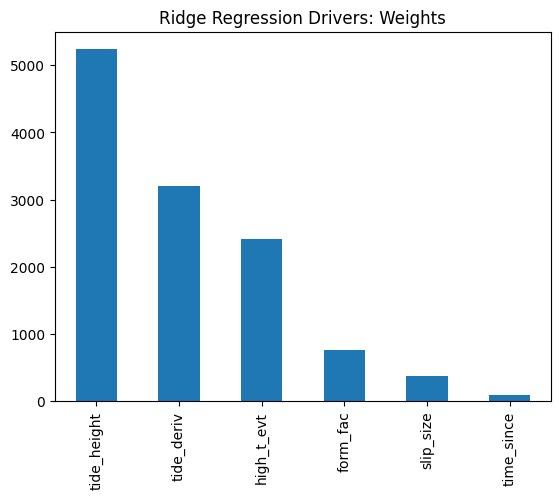

In [ ]:

#Plot of drivers with weights

plt.figure()
drivers.abs().plot.bar()
plt.title("Ridge Regression Drivers: Weights")
plt.show()


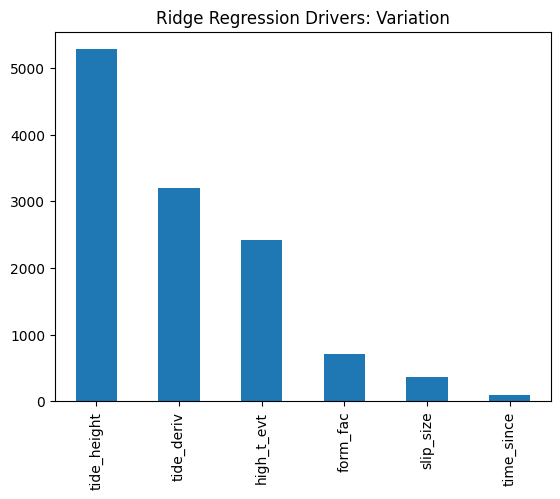

In [ ]:
#Plot of drivers with varience:
plt.figure()
drivers_vari.abs().plot.bar()
plt.title("Ridge Regression Drivers: Variation")
plt.show()

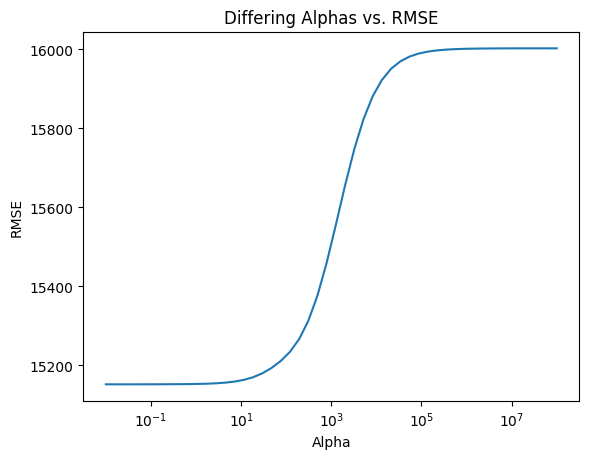

In [ ]:
# Alpha values vs MAE
plt.figure()
plt.plot(alphas, val_RMSE)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Differing Alphas vs. RMSE')
plt.show()

#Multiplicative Error vs Actual Value for Ridge Regression

#Error in terms of seconds for Ridge Regression (may need to unscale and then recompute a MAE for this one)


In [ ]:
'''hat about the data set drove getting that optimal alpha value:
correlation = X_train.corr().abs() #Seeing correlation of the features
plt.figure(figsize=(12,10)) #Visualizing the feature correlation
sns.heatmap(correlation, cmap='coolwarm', center=0)
plt.title('Correlation Strength Between Features')
plt.show()
#print("Feature correlation:", correlation)

#Statistical measure of whether there are likely redundant features (checking linear independence)
condition = np.linalg.cond(X_train)
print("Condition Number:", condition)'''

'hat about the data set drove getting that optimal alpha value:\ncorrelation = X_train.corr().abs() #Seeing correlation of the features\nplt.figure(figsize=(12,10)) #Visualizing the feature correlation\nsns.heatmap(correlation, cmap=\'coolwarm\', center=0)\nplt.title(\'Correlation Strength Between Features\')\nplt.show()\n#print("Feature correlation:", correlation)\n\n#Statistical measure of whether there are likely redundant features (checking linear independence)\ncondition = np.linalg.cond(X_train)\nprint("Condition Number:", condition)'

Sample0: True = 56625.00s, Predicted = 55764.35s, Error=860.65s
Sample1: True = 55155.00s, Predicted = 54637.89s, Error=517.11s
Sample2: True = 35550.00s, Predicted = 46048.84s, Error=10498.84s
Sample3: True = 44835.00s, Predicted = 52760.03s, Error=7925.03s
Sample4: True = 35430.00s, Predicted = 44579.84s, Error=9149.84s
Sample5: True = 50205.00s, Predicted = 55556.50s, Error=5351.50s
Sample6: True = 50010.00s, Predicted = 55541.76s, Error=5531.76s
Sample7: True = 47985.00s, Predicted = 52343.99s, Error=4358.99s
Sample8: True = 85185.00s, Predicted = 45948.12s, Error=39236.88s
Sample9: True = 48525.00s, Predicted = 53212.66s, Error=4687.66s
Sample10: True = 59025.00s, Predicted = 60455.82s, Error=1430.82s
Sample11: True = 35955.00s, Predicted = 48130.29s, Error=12175.29s
Sample12: True = 51195.00s, Predicted = 54100.67s, Error=2905.67s
Sample13: True = 34440.00s, Predicted = 41458.64s, Error=7018.64s
Sample14: True = 39390.00s, Predicted = 44793.56s, Error=5403.56s
Sample15: True = 51

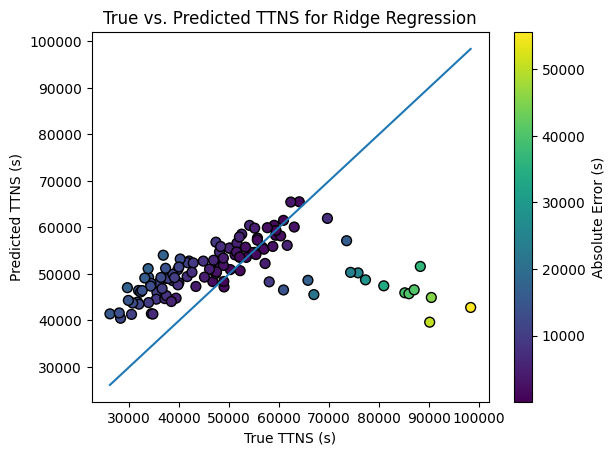

In [ ]:
# Ridge Prediction Analysis:

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = Ridge_prediction

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Ridge Regression")
plt.show()